In [2]:
def selection_sort(arr):
    """选择排序算法"""
    n = len(arr)
    # 遍历所有数组元素
    for i in range(n):
        # 找到剩余部分中最小元素的索引
        min_idx = i
        for j in range(i + 1, n):
            if arr[j] < arr[min_idx]:
                min_idx = j
                
        # 将找到的最小元素与当前位置元素交换
        arr[i], arr[min_idx] = arr[min_idx], arr[i]
    return arr

def test():
    """测试函数：执行数据输入，调用排序并输出结果"""
    # 提示用户输入一组数字，用空格隔开
    input_str = input("请输入需要排序的数字（用空格隔开，例如: 64 25 12 22 11）：")
    
    # 将输入的字符串转换为整数列表
    try:
        data = [int(x) for x in input_str.split()]
        print("排序前的数组:", data)
        
        # 调用选择排序
        sorted_data = selection_sort(data)
        print("排序后的结果:", sorted_data)
    except ValueError:
        print("输入错误！请确保输入的全部是数字，并用空格隔开。")

# 执行测试
test()

请输入需要排序的数字（用空格隔开，例如: 64 25 12 22 11）： 11


排序前的数组: [11]
排序后的结果: [11]


In [1]:
import pandas as pd
import numpy as np

# 1. 模拟实验大纲中的财富500强数据集
data_dict = {
    "year": [1955, 1955, 1955, 1955, 1955, 1956, 1956],
    "rank": [229, 291, 295, 297, 353, 1, 2],
    "company": ["Norton", "Schlitz Brewing", "Pacific Vegetable Oil", "Liebmann Breweries", "Minneapolis-Moline", "General Motors", "Exxon Mobil"],
    "revenue": [135.0, 100.0, 97.9, 96.0, 77.4, 400.0, 350.0],
    "profit": ["N.A.", "N.A.", "N.A.", "N.A.", "N.A.", "20.5", "18.2"] # 包含N.A.异常值
}
df = pd.DataFrame(data_dict)
print("--- 原始数据集（包含异常值） ---")
print(df)

# 2. 数据清洗：找出 profit 列中为 "N.A." 的行，并将其过滤掉
df_clean = df[df['profit'] != 'N.A.'].copy()

# 将清洗后的 profit 和 revenue 列转换为浮点数格式，以便后续画图
df_clean['profit'] = df_clean['profit'].astype(float)
df_clean['revenue'] = df_clean['revenue'].astype(float)

print("\n--- 清洗后的数据集（已删除利润为 N.A. 的行） ---")
print(df_clean)

--- 原始数据集（包含异常值） ---
   year  rank                company  revenue profit
0  1955   229                 Norton    135.0   N.A.
1  1955   291        Schlitz Brewing    100.0   N.A.
2  1955   295  Pacific Vegetable Oil     97.9   N.A.
3  1955   297     Liebmann Breweries     96.0   N.A.
4  1955   353     Minneapolis-Moline     77.4   N.A.
5  1956     1         General Motors    400.0   20.5
6  1956     2            Exxon Mobil    350.0   18.2

--- 清洗后的数据集（已删除利润为 N.A. 的行） ---
   year  rank         company  revenue  profit
5  1956     1  General Motors    400.0    20.5
6  1956     2     Exxon Mobil    350.0    18.2


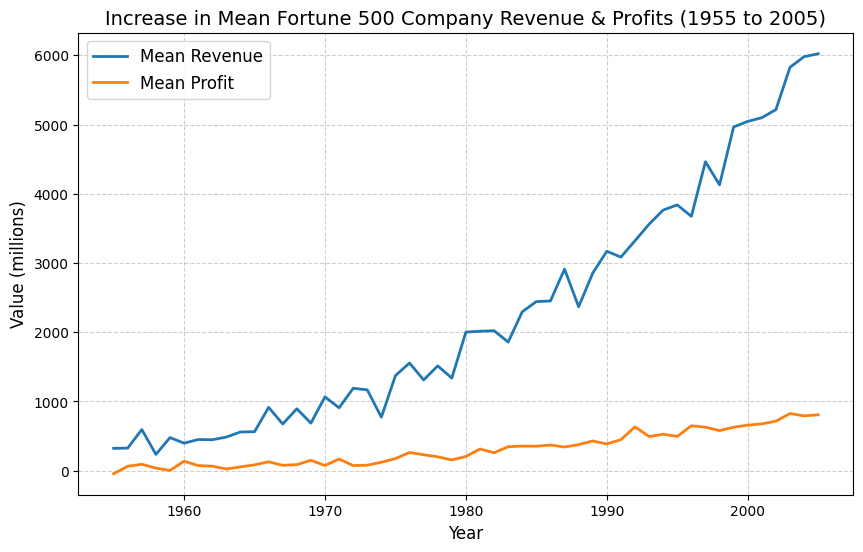

In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 

# 为了画出类似大纲中随年份变化的连续折线图，我们模拟一段 1955-2005 的趋势数据
years = list(range(1955, 2006))
# 模拟利润（总体上升，伴随波动）
mock_profit = [20 + (y - 1955)**1.7 + np.random.normal(0, 50) for y in years]
# 模拟收入（数值通常远高于利润）
mock_revenue = [500 + (y - 1955)**2.2 + np.random.normal(0, 200) for y in years]

# 创建一个数据框
df_trend = pd.DataFrame({
    'year': years,
    'profit': mock_profit,
    'revenue': mock_revenue
})

# --- 开始画图：在同一张图里同时绘制利润和收入 ---
plt.figure(figsize=(10, 6))

# 绘制收入折线（蓝色）
plt.plot(df_trend['year'], df_trend['revenue'], label='Mean Revenue', color='#1f77b4', linewidth=2)

# 绘制利润折线（橙色）
plt.plot(df_trend['year'], df_trend['profit'], label='Mean Profit', color='#ff7f0e', linewidth=2)

# 添加图表元素
plt.title("Increase in Mean Fortune 500 Company Revenue & Profits (1955 to 2005)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Value (millions)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6) # 添加网格线
plt.legend(fontsize=12) # 显示图例

# 显示图形
plt.show()